In [1]:
days_holding = "3"
top_percentile = "0.95"
bottom_percentile = "0.00"
days_momentum_score = "40"
days_momentum_gate = ""
min_volume = "1_000_000"

In [2]:
days_holding_P = int(days_holding)
top_percentile_P = float(top_percentile)
bottom_percentile_P = (
    float(bottom_percentile) if bottom_percentile != "None" else None
)
days_momentum_score_P = int(days_momentum_score)
days_momentum_gate_P = [int(n) for n in days_momentum_gate.split(",") if n != ""]
min_volume_P = int(min_volume)

print(f"""
days_holding: {days_holding_P}
days_momentum_score: {days_momentum_score_P}
days_momentum_gate: {days_momentum_gate_P}
min_volume: {min_volume_P}

top_percentile: {top_percentile_P}
bottom_percentile: {bottom_percentile_P}
""")


days_holding: 3
days_momentum_score: 40
days_momentum_gate: []
min_volume: 1000000

top_percentile: 0.95
bottom_percentile: 0.0



100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2325/2325 [00:05<00:00, 448.15it/s]


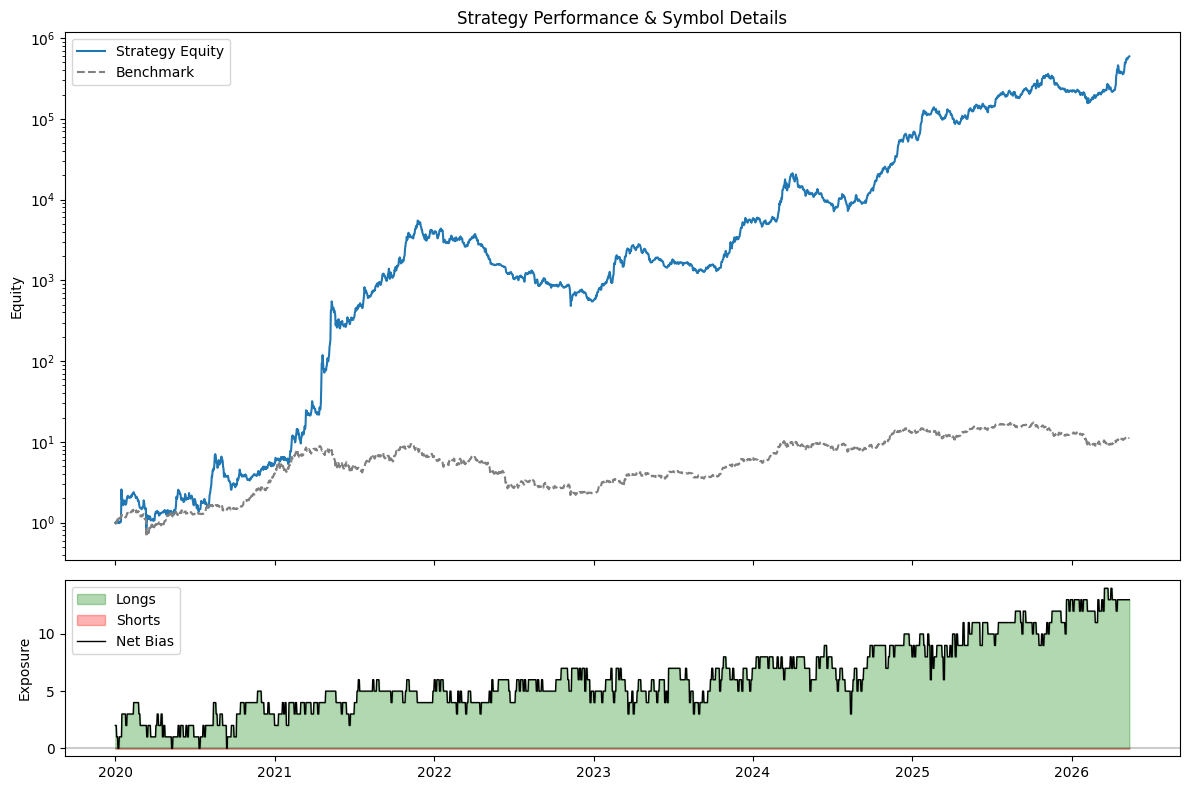

mae: -0.13179561202613693 (None)


ann_std: 1.0585650202495267 (0.4856679350258086)


cagr: 103.6068789001682 (0.7630881407526532)


mae_std: 0.15396631014380438 (None)


fees: 5572.140523764372 (None)


...

ann_return: 2.04272122832031 (0.3583053278774253)


sortino: 4.346015624472812 (1.3550703078615156)


mfe_std: 1.5840691369481343 (None)


sharpe: 1.702842150440811 (0.726904481129013)


ir: 1.4098615114071535 (None)


In [3]:
import datetime as dt
import polars as pl
import scrapbook as sb
import backtest as bt
import functools as fc
import operator

df = (
    pl.read_parquet("polarity/latest-data/*parquet")
    .rename(
        {
            "asset": "symbol",
            "price": "close",
        }
    )
    .with_columns(ts=pl.col("ts").dt.cast_time_unit("us"))

    #.join(
    #    pl.read_parquet('stables-1d.parquet')
    #    .with_columns(
    #        ts=pl.col("ts").dt.cast_time_unit("us").dt.replace_time_zone(None),
    #        symbol=pl.col('symbol').str.to_lowercase().str.strip_suffix('usdt'),
    #    ),
    #    on=['ts','symbol'],
    #    how='inner'
    #)
    .sort(["symbol", "ts"])
    .with_columns(**{
        f'mom{n}': pl.col("close").pct_change(n).over("symbol")
        for n in set([days_momentum_score_P, *days_momentum_gate_P])
    })
    .with_columns(
        rank=(
            pl.col(f"mom{days_momentum_score_P}").rank(method="ordinal").over("ts")
            / pl.col(f"mom{days_momentum_score_P}").count().over("ts")
        ),
        volume=pl.col('total_volume').rolling_mean(days_holding_P).over('symbol'),
    )
    .sort("ts")
    .filter(pl.col("ts").dt.year() >= 2020)
    .drop_nulls(['volume'])
)

#print(df)

#df = (
#    df.join(
#        df.filter(pl.col('symbol') == 'btc')
#        .sort(["symbol", "ts"])
#        .select(
#            ts=pl.col('ts'),
##            mkt=(pl.col('close') - pl.col('mdccv')) / pl.col('close'),
#            mktdelta=pl.col('mdccv').diff(5).over('symbol'),
#        ),
#        on='ts',
#        how='inner',
#    )
#)

class Alpha(bt.AlphaModel):
    def __init__(self, long_expr: pl.Expr, short_expr: pl.Expr):
        self.long_expr = long_expr
        self.short_expr = short_expr

    def __call__(self, df: pl.DataFrame) -> list[bt.Signal]:
        today = df["ts"].max()
        dfnow = df.filter(pl.col("ts") == today)
        l = dfnow.filter(self.long_expr)
        s = dfnow.filter(self.short_expr)

        return [
            bt.Signal(r['symbol'], True, r['rank'])
            for r in l.iter_rows(named=True)
        ] + [
            bt.Signal(r['symbol'], False, 1-r['rank'])
            for r in s.iter_rows(named=True)
        ]

if len(days_momentum_gate_P) > 0:
    long_gate_expr = fc.reduce(operator.or_, [pl.col(f'mom{n}') > 0 for n in days_momentum_gate_P]) & (pl.col('mkt') > -0.0)
    short_gate_expr = fc.reduce(operator.and_, [pl.col(f'mom{n}') < 0 for n in days_momentum_gate_P]) & (pl.col('mkt') < -0.15)
else:
    long_gate_expr = pl.lit(True)
    short_gate_expr = pl.lit(True)


test = bt.Backtest(
    df,
    alpha=Alpha(
        long_expr=(pl.col("rank") >= top_percentile_P) & long_gate_expr & (pl.col('volume') > min_volume_P),
        short_expr=(
            (pl.col("rank") <= bottom_percentile_P) & short_gate_expr & (pl.col('volume') > min_volume_P)
            if bottom_percentile_P is not None
            else pl.lit(False)
        ),
    ),
    #portfolio=bt.VolumeWeighted(),
    #risk=bt.MaxDrawdown(.1, .1),
    benchmark="btc",
    period=days_holding_P,
    eager_rebalance=True,
)

test.run()
res = test.report(plot=True)

for col in set(res.columns) - {'year', 'src'}:
    s = res.filter(pl.col('src') == 'Strategy')
    b = res.filter(pl.col('src') == 'Benchmark')

    print(f"{col}: {s[col].mean()} ({b[col].mean()})")
    sb.glue(col,s[col].mean())

In [4]:
print(
    test.live(equity=10_000)
    .select(
        pl.col('entry_ts').dt.strftime('%Y-%m-%d'),
        pl.col('symbol').str.to_uppercase(),
        pl.lit(''),
        pl.col('entry_price'),
        pl.col('shares'),
        (pl.col('entry_price') * pl.col('shares')).alias('cost'),
    )
    .sort('symbol')
    .write_csv()
)

entry_ts,symbol,literal,entry_price,shares,cost
2026-05-13,B,"",0.6282308163462689,1224.4397269534513,769.2307692307693
2026-05-13,GWEI,"",0.12362052812350698,6222.516445345105,769.2307692307693
2026-05-13,H,"",0.23803598322728695,3231.5734738990063,769.2307692307693
2026-05-13,LAB,"",4.861977540054092,158.21355876156747,769.2307692307693
2026-05-13,LUNC,"",0.00009157839473944873,8399697.018268567,769.2307692307693
2026-05-13,PRIME,"",1.036,742.5007425007425,769.2307692307693
2026-05-13,RAVE,"",0.681051801901217,1129.4746847205938,769.2307692307693
2026-05-13,SIREN,"",1.1551865018622995,665.8931419218254,769.2307692307693
2026-05-13,SKYAI,"",0.5386978071976347,1427.9448680743521,769.2307692307693
2026-05-13,UB,"",0.171424676544126,4487.281438928447,769.2307692307693
2026-05-13,VVV,"",16.319012857175892,47.13708947735271,769.2307692307693
2026-05-13,ZEC,"",570.2347082668837,1.3489722005324702,769.2307692307693
2026-05-13,币安人生,"",0.4095688592805119,1878.1475978961735,769.2307692307693

